<a href="https://colab.research.google.com/github/teemus28/Machine-Learning/blob/main/ML_Adaboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
data = {'x1':[1,2,3,4,5,6,6,7,9,9],
        'x2':[5,3,6,8,1,9,5,8,9,2],
        'label':[1,1,0,1,0,1,0,1,0,0]}

In [ ]:
df = pd.DataFrame(data)

In [ ]:
df

,x1,x2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='x1', ylabel='x2'>

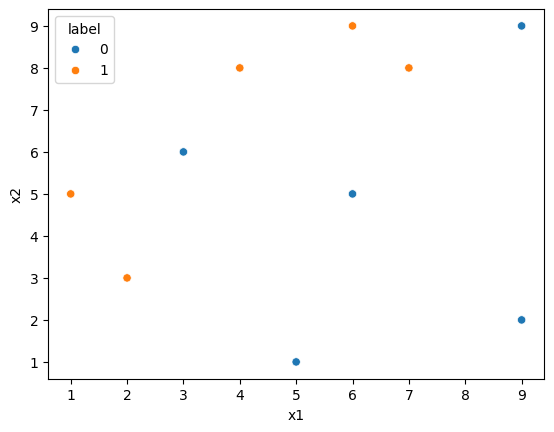

In [ ]:
import seaborn as sbn
sbn.scatterplot(x = df['x1'],y = df['x2'],hue = df['label'])

In [ ]:
#step 1 - initialize ,  W0 = 1/n

df['weights'] = 1/df.shape[0]

In [ ]:
df

,x1,x2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [ ]:
x = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
#2 Train data with model_1

clf1 = DecisionTreeClassifier(max_depth=1)

In [ ]:
clf1.fit(x,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

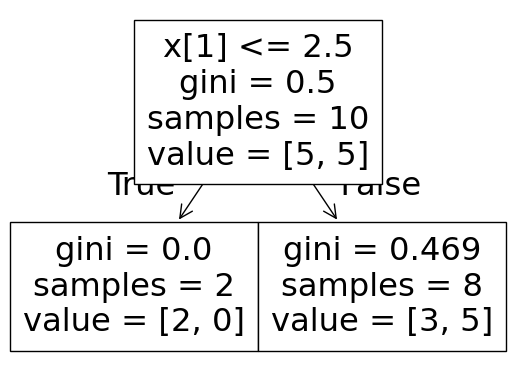

In [ ]:
from sklearn.tree import plot_tree
plot_tree(clf1)

In [ ]:
from mlxtend.plotting import plot_decision_regions    #visualize the decision boundaries of classifiers

<Axes: >

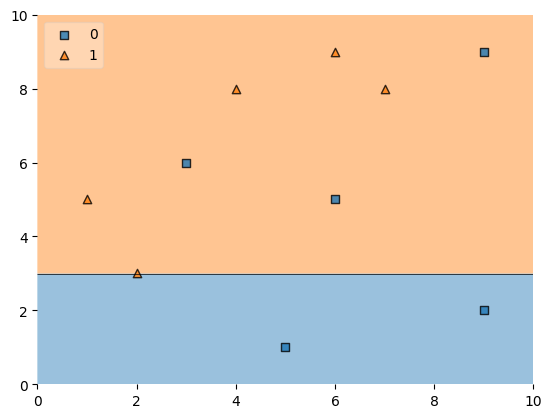

In [ ]:
plot_decision_regions(x,y,clf1,legend=2)      #decision stump

In [ ]:
df['y_pred'] = clf1.predict(x)

In [ ]:
df

,x1,x2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [ ]:
import numpy as np
np.log(np.exp(1))

1.0

In [ ]:
#step 3 - calculate model weight , alpha = 0.5 log(E/1-E)

def calculate_model_weight(error):

  return 0.5*np.log((1-error)/(error))

In [ ]:
alpha1 = calculate_model_weight(0.3)
alpha1

0.42364893019360184

In [ ]:
# step 4 - update weights , correct - wn = w0*e^(-alpha) , incorrect - wn = w0*e^(alpha)

def update_row_weights(row,alpha=0.423):
  if (row['label'] == row['y_pred']):
    return row['weights']*np.exp(-alpha)
  else:
    return row['weights']*np.exp(alpha)

In [ ]:
df['updated_weights'] = df.apply(update_row_weights,axis=1)     #apply function to each column of df

In [ ]:
df

,x1,x2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [ ]:
df['updated_weights'].sum()

0.9165153319682015

In [ ]:
print(0.065508/0.9165153319682015)

0.07147507271844832


In [ ]:
df['normalized_weight'] = df['updated_weights']/df['updated_weights'].sum()

In [ ]:
df

,x1,x2,label,weights,y_pred,updated_weights,normalised_weight,normalized_weight
0,1,5,1,0.1,1,0.065508,0.071475,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.071475
2,3,6,0,0.1,1,0.152653,0.166559,0.166559
3,4,8,1,0.1,1,0.065508,0.071475,0.071475
4,5,1,0,0.1,0,0.065508,0.071475,0.071475
5,6,9,1,0.1,1,0.065508,0.071475,0.071475
6,6,5,0,0.1,1,0.152653,0.166559,0.166559
7,7,8,1,0.1,1,0.065508,0.071475,0.071475
8,9,9,0,0.1,1,0.152653,0.166559,0.166559
9,9,2,0,0.1,0,0.065508,0.071475,0.071475


In [ ]:
df['normalized_weight'].sum()

1.0

In [ ]:
df['cumsum_upper'] = np.cumsum(df['normalized_weight'])      #cumulative sum , [1, 2, 3, 4] - [ 1  3  6 10]

In [ ]:
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weight']

In [ ]:
df[['x1','x2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,x1,x2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,1,0.152653,0.142950,0.309508
3,4,8,1,0.1,1,0.065508,0.309508,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,1,0.065508,0.452458,0.523933
6,6,5,0,0.1,1,0.152653,0.523933,0.690492
7,7,8,1,0.1,1,0.065508,0.690492,0.761967
8,9,9,0,0.1,1,0.152653,0.761967,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [ ]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [ ]:
index_values = create_new_dataset(df)

index_values

[2, 2, 9, 8, 4, 2, 4, 4, 8, 0]

In [ ]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [ ]:
second_df

,x1,x2,label,weights
2,3,6,0,0.1
2,3,6,0,0.1
9,9,2,0,0.1
8,9,9,0,0.1
4,5,1,0,0.1
2,3,6,0,0.1
4,5,1,0,0.1
4,5,1,0,0.1
8,9,9,0,0.1
0,1,5,1,0.1


In [ ]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [ ]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [ ]:
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.0\ngini = 0.18\nsamples = 10\nvalue = [9, 1]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.625, 0.5, '  False')]

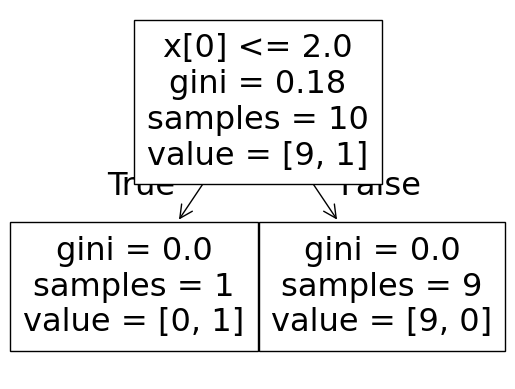

In [ ]:
plot_tree(dt2)

<Axes: >

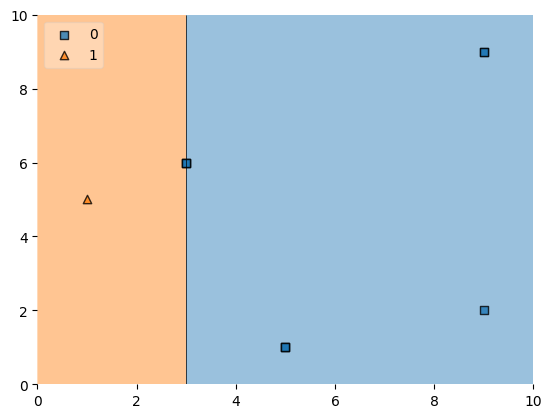

In [ ]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [ ]:
second_df['y_pred'] = dt2.predict(X)

In [ ]:
second_df

,x1,x2,label,weights,y_pred
2,3,6,0,0.1,0
2,3,6,0,0.1,0
9,9,2,0,0.1,0
8,9,9,0,0.1,0
4,5,1,0,0.1,0
2,3,6,0,0.1,0
4,5,1,0,0.1,0
4,5,1,0,0.1,0
8,9,9,0,0.1,0
0,1,5,1,0.1,1
